# Scatter Plots for Meridian and Horizon Text Parts

Visualizing text-parts across time and place for images where 'multiple lines' (material object (double lines)) is 'yes'.

In [7]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [8]:
# Load datasets
try:
    df = pd.read_csv('../DATA/02_image_clusters/full_image_data_feb_25.csv', low_memory=False)
except FileNotFoundError:
    df = pd.read_csv('../DATA/02_image_clusters/full_image_data_feb_25.csv', low_memory=False)

try:
    books = pd.read_csv('../DATA/01_corpus_metadata/full_book_data_feb_25.csv', low_memory=False)
except FileNotFoundError:
    books = pd.read_csv('../DATA/01_corpus_metadata/full_book_data_feb_25.csv', low_memory=False)

vt = pd.read_excel('../DATA/04_visual_tags/visual_tags/VT_2.3.xlsx')

# Merge printer/publisher info
printer_pub = books[['book', 'printers', 'publishers']].drop_duplicates(subset=['book'])
df = df.merge(printer_pub, on='book', how='left')


In [9]:
# Filter visual tags for "multiple lines" ('material object (double lines)' == 'yes')
double_lines_clusters = vt[vt['material object (double lines)'] == 'yes']['cluster_name'].tolist()

# Target CKs
target_cks = ['CK_Horizon', 'CK_Meridian', 'CK_Meridian Dial']

# Ensure cks is string
df['cks'] = df['cks'].astype(str)

# Apply filters
mask_cks = df['cks'].apply(lambda x: any(ck in x for ck in target_cks))
mask_cluster = df['cluster_name'].isin(double_lines_clusters)

filtered_df = df[mask_cks & mask_cluster].copy()

print(f"Total images matching criteria: {len(filtered_df)}")


Total images matching criteria: 204


### Data Cleaning for Plots

In [10]:
filtered_df['custom_identifier_str'] = filtered_df['custom_identifier'].astype(str)

filtered_df['year'] = pd.to_numeric(filtered_df['year'], errors='coerce')
plot_df = filtered_df.dropna(subset=['year', 'place']).copy()

plot_df = plot_df.sort_values(by=['place', 'year'])


### 1. Static Scatter Plot (Y = Place, Color = Custom ID)

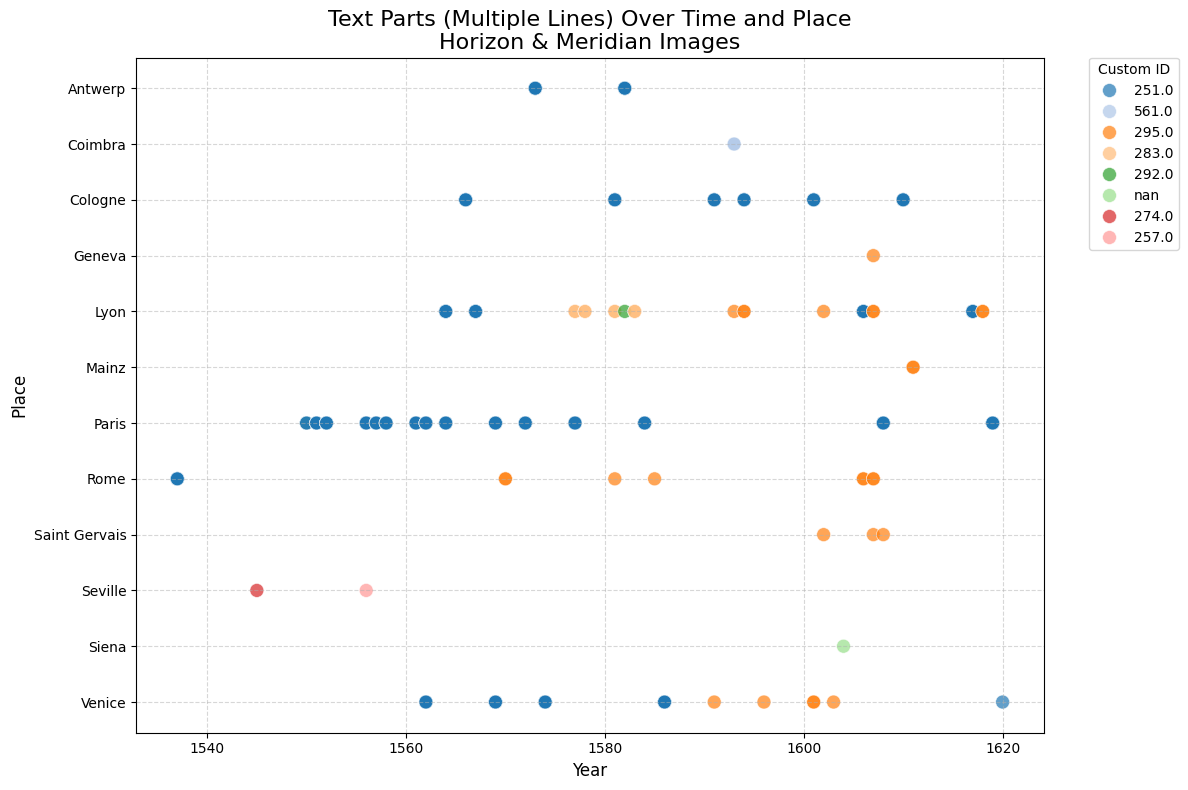

In [11]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=plot_df,
    x='year',
    y='place',
    hue='custom_identifier_str',
    palette='tab20',
    s=100,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Text Parts (Multiple Lines) Over Time and Place\nHorizon & Meridian Images', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Place', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Custom ID')
plt.tight_layout()

plt.savefig('/Users/nogashlomi/Desktop/horizon_meridian_lines.png', dpi=300)
plt.show()


### 2. Interactive Scatter Plot (Y = Place, Color = Custom ID)

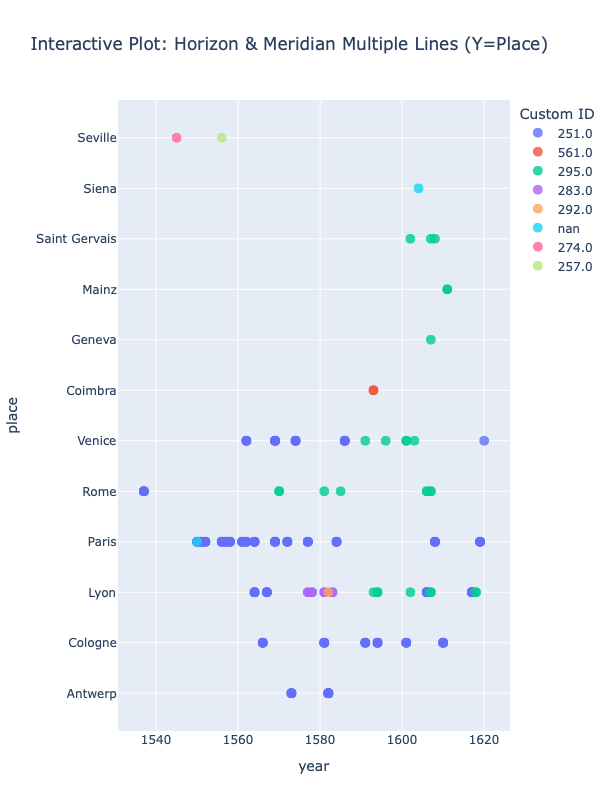

In [12]:
fig_interactive = px.scatter(
    plot_df,
    x='year',
    y='place',
    color='custom_identifier_str',
    hover_data=['part_or_adaption_label', 'part_or_adaption', 'part_type', 'cks', 'bid'],
    title='Interactive Plot: Horizon & Meridian Multiple Lines (Y=Place)',
    labels={'custom_identifier_str': 'Custom ID'}
)

fig_interactive.update_traces(marker=dict(size=10, opacity=0.8))
fig_interactive.update_layout(height=800, hovermode='closest')
fig_interactive.show()


### 3. Static Scatter Plot (Y = Custom ID, Color = Place)

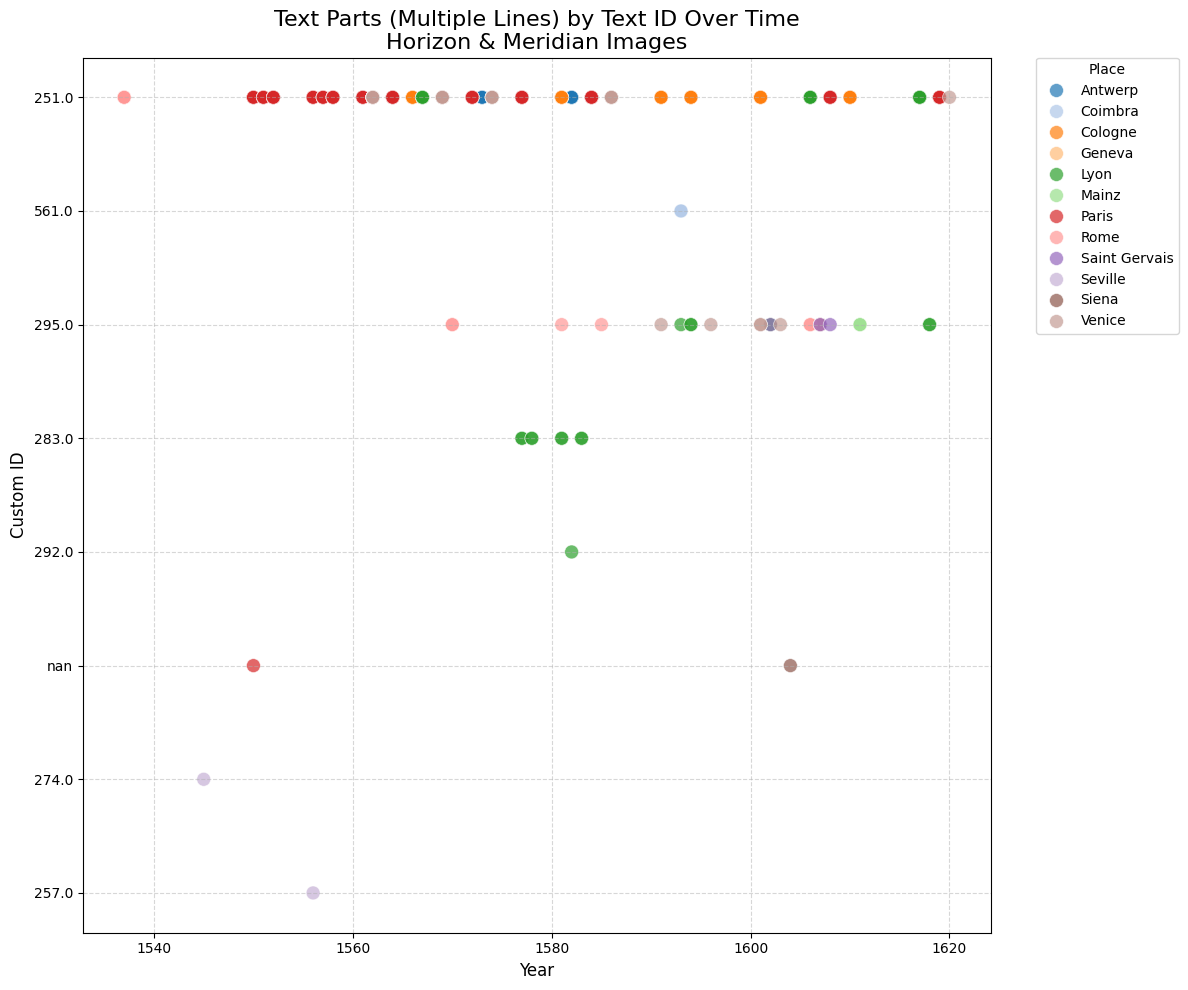

In [13]:
plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=plot_df,
    x='year',
    y='custom_identifier_str',
    hue='place',
    palette='tab20',
    s=100,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Text Parts (Multiple Lines) by Text ID Over Time\nHorizon & Meridian Images', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Custom ID', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Place')
plt.tight_layout()

plt.savefig('/Users/nogashlomi/Desktop/horizon_meridian_lines_by_id.png', dpi=300)
plt.show()


### 4. Interactive Scatter Plot (Y = Custom ID, Color = Place)

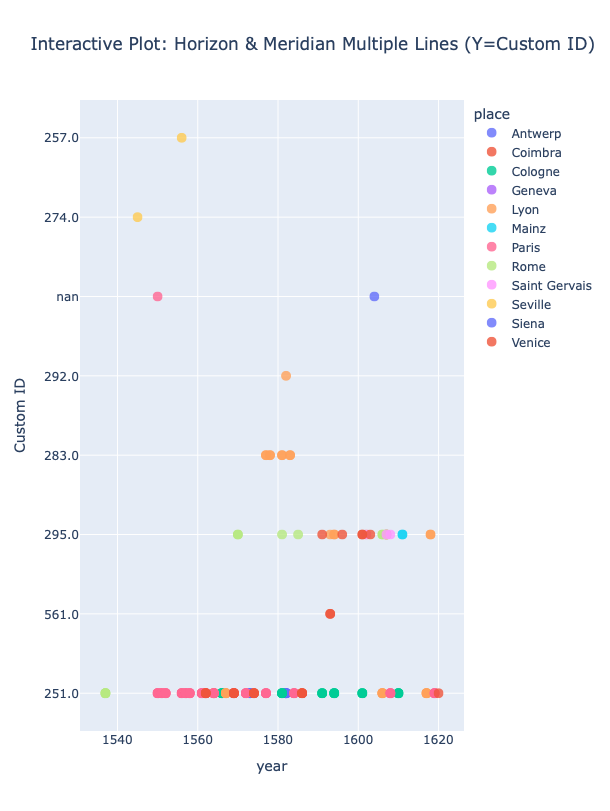

In [14]:
fig_interactive2 = px.scatter(
    plot_df,
    x='year',
    y='custom_identifier_str',
    color='place',
    hover_data=['part_or_adaption_label', 'part_or_adaption', 'part_type', 'cks', 'bid'],
    title='Interactive Plot: Horizon & Meridian Multiple Lines (Y=Custom ID)',
    labels={'custom_identifier_str': 'Custom ID'}
)

fig_interactive2.update_traces(marker=dict(size=10, opacity=0.8))
fig_interactive2.update_layout(height=800, hovermode='closest')
fig_interactive2.show()
